# Modeling: EV Profit Targeting

Run after `feature_selection.ipynb`. Outputs → `outputs/ev_profit_targeting/`.


## Flow

1. `setup_modeling_notebook` — style + data (excludes `top_26`)
2. LightGBM + logistic comparison → HPO → EV k selection
3. Export test submission


In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from cost_effective.models import TargetingConfig, compute_oof_probabilities
from cost_effective.notebook_setup import setup_modeling_notebook
from cost_effective.notebook_workflows import (
    build_estimator_factories,
    evaluate_ev_oof,
    export_ev_test_predictions,
    run_model_comparison,
    save_tuned_comparison,
    select_winner_from_candidates,
    stage_matrices,
    tune_winner,
)
from cost_effective.paths import APPROACH_EV_PROFIT_TARGETING
from cost_effective.plots import plot_ev_targeting_dashboard
from cost_effective.utils import HPO_N_ITER

In [3]:
TARGETING = TargetingConfig(
    max_targets=1000,
    k_selection_strategy="combined",
    calibrate_probabilities=True,
    elbow_score_fraction=0.95,
)

ctx = setup_modeling_notebook(APPROACH_EV_PROFIT_TARGETING, exclude_top_26=True)
_, y_train, x_test, x_stage2 = stage_matrices(ctx)
feature_sets = ctx.stage.feature_set_candidates
list(feature_sets)

['top_01', 'top_03', 'top_05', 'top_08', 'top_10', 'top_15', 'top_20']

In [4]:
factories = build_estimator_factories(ctx, model_names=("lightgbm", "logistic_regression"))
comparison_base = run_model_comparison(ctx, estimator_factories=factories)
comparison_base.to_csv(ctx.outputs_path / "model_comparison_base.csv", index=False)

winner = select_winner_from_candidates(comparison_base, feature_sets)
x_best = x_stage2[winner.features]

winner

WinnerSelection(model_name='logistic_regression', feature_set_name='top_01', features=['var_389'], cv_score_mean=2306.0)

In [5]:
best_est, best_params, hpo_cv, tuned_factory = tune_winner(
    ctx,
    winner,
    factories[winner.model_name],
    x_best,
    hpo_n_iter=HPO_N_ITER,
)

save_tuned_comparison(
    ctx,
    winner,
    tuned_factory,
    best_params,
    feature_set_candidates={winner.feature_set_name: winner.features},
)

,model_name,feature_set_name,feature_count,cv_score_mean,cv_score_std,f1_score,roc_auc_score,business_score_no_var_penalty,best_hyperparams
0,logistic_regression,top_01,1,2306.0,20.34699,0.668303,0.555137,2506.0,"{""logisticregression__C"": 0.001, ""logisticregr..."


In [6]:
oof_probabilities = compute_oof_probabilities(
    x_best, y_train, estimator_factory=tuned_factory, cv=5
)

oof_eval = evaluate_ev_oof(y_train, oof_probabilities, len(winner.features), TARGETING)
for line in oof_eval.summary_lines:
    print(line)
oof_eval.confusion_matrix

Strategy: combined
Selected k (OOF): 939
  k_ev=1000, k_elbow=939, k_nested=1000, k_curve_max=999
OOF business=3145 (TP=536, FP=403)
OOF n(p>=1/3)=4860, min p in top-k=0.5430
OOF ROC-AUC (uncalibrated): 0.5543


,Predicted 0,Predicted 1
Actual 0,2102,410
Actual 1,1959,529


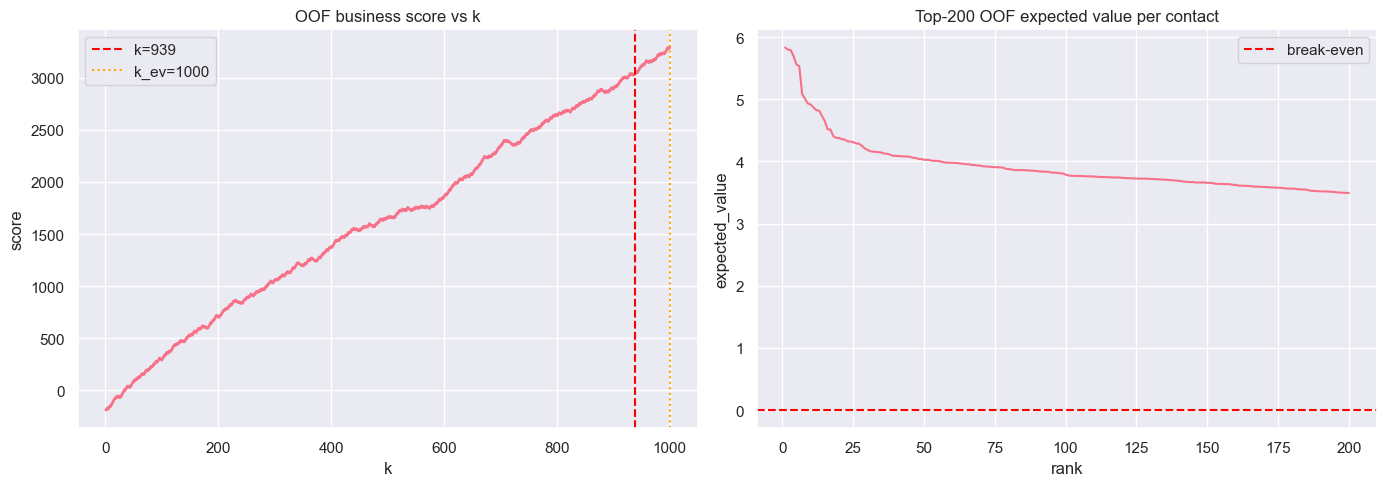

In [7]:
plot_ev_targeting_dashboard(oof_eval.profit_curve, oof_eval.targeting, oof_probabilities).show()

In [8]:
predictions, test_diag = export_ev_test_predictions(
    ctx,
    winner,
    x_stage2,
    y_train,
    x_test,
    tuned_factory,
    oof_eval,
    cv_business_mean=winner.cv_score_mean,
    hpo_cv=hpo_cv,
)
test_diag

{'requested_k': 939.0,
 'exported_k': 939.0,
 'n_test_above_break_even': 4989.0,
 'min_prob_in_export': 0.5226824497237276,
 'max_prob_in_export': 0.7354275870713015}

In [9]:
predictions.head()

,rank,sample_index,probability,expected_value
0,1,4134,0.735428,6.031414
1,2,1691,0.721564,5.823461
2,3,2916,0.714486,5.717288
3,4,4403,0.693772,5.406579
4,5,588,0.687017,5.305259
